**Image Classification System Using Convolutional Neural Networks**

In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow.keras.datasets import cifar10

In [7]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


In [8]:
CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

*loading the dataset*

In [9]:
(X_train_full,Y_train_full),(X_test,Y_test) = cifar10.load_data()

*Exploring the dataset*

In [10]:
print("Training images shape:",X_train_full.shape)
print("training labels shape:",Y_train_full.shape)
print("Test images shape:",X_test.shape)
print("test labels shape:",Y_test.shape)

Training images shape: (50000, 32, 32, 3)
training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
test labels shape: (10000, 1)


In [11]:
print("pixel value range",X_train_full.min(),"to",X_train_full.max())

pixel value range 0 to 255


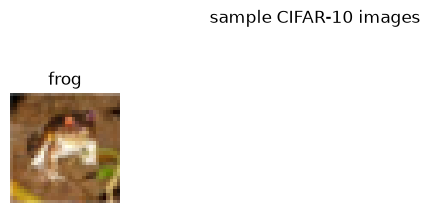

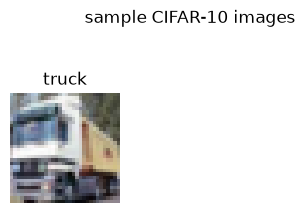

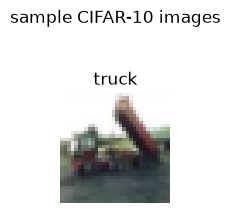

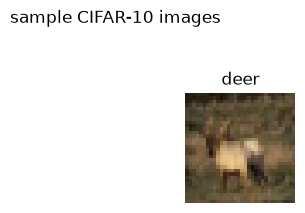

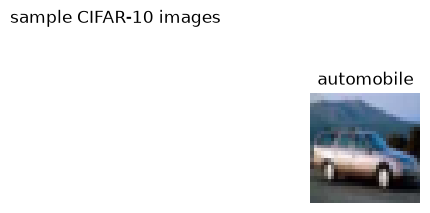

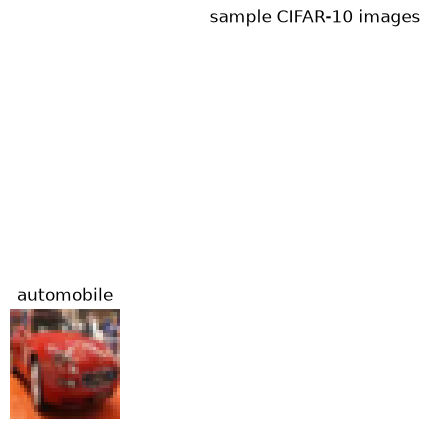

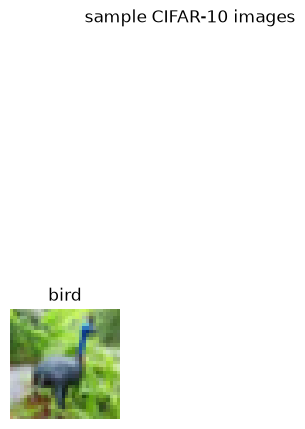

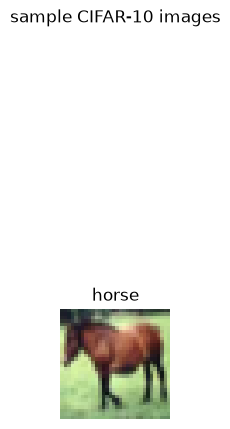

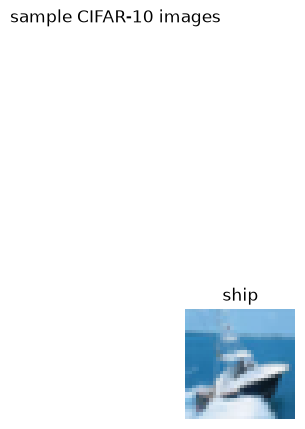

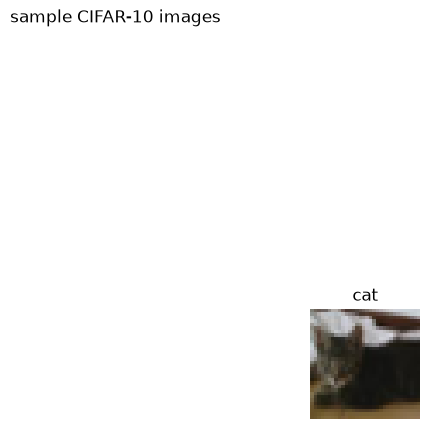

In [12]:
plt.Figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_full[i])
    plt.title(CLASS_NAMES[Y_train_full[i][0]])
    plt.axis('off')
    plt.suptitle("sample CIFAR-10 images")
    plt.tight_layout()
    plt.show()

In [13]:
print("single image shape:",X_train_full[0].shape)

single image shape: (32, 32, 3)


In [14]:
print("no of classes", len(CLASS_NAMES))

no of classes 10


*normalisation*

In [15]:
X_train_full = X_train_full.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

*train test valuation split*

In [16]:
x_train,x_val,y_train,y_val = train_test_split(X_train_full,Y_train_full,test_size=0.2,random_state=42)

In [17]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)
y_test_cat = to_categorical(Y_test, num_classes=10)

**CNN MODEL**

In [18]:
model = Sequential([
Conv2D(32,(3,3),activation ='relu',padding='same',input_shape = (32,32,3)),
MaxPool2D((2,2)),
Conv2D(64,(3,3),activation ='relu',padding='same'),
MaxPool2D((2,2)),
Conv2D(64,(3,3),activation='relu',padding='same'),
Flatten(),Dense(64,activation='relu'),Dense(10,activation='softmax')
])

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

*compiling the model*

In [20]:
model.compile(
    optimizer = Adam(),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

*TRAINING*

In [21]:
EPOCHS = 15
BATCH_SIZE = 64

In [22]:
history = model.fit(
    x_train,y_train_cat,
    validation_data = (x_val,y_val_cat),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.4453 - loss: 1.5300 - val_accuracy: 0.5415 - val_loss: 1.3049
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6072 - loss: 1.1108 - val_accuracy: 0.6178 - val_loss: 1.0749
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6688 - loss: 0.9476 - val_accuracy: 0.6724 - val_loss: 0.9406
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7092 - loss: 0.8299 - val_accuracy: 0.6904 - val_loss: 0.8851
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7356 - loss: 0.7544 - val_accuracy: 0.6969 - val_loss: 0.8776
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7643 - loss: 0.6771 - val_accuracy: 0.7110 - val_loss: 0.8420
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7870 - loss: 0.6074 - val_accuracy: 0.7234 - val_loss: 0.8096
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8052 - loss: 0.5534 - 

*accuracy graph*